# Polynomial Regression

## Importing the libraries

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## Importing the dataset

In [3]:
# Load the dataset
data = pd.read_csv('data.csv')

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
   Temperature (°C)  Ice Cream Sales
0                 0              0.5
1                 2              0.8
2                 4              1.2
3                 6              2.0
4                 8              3.0


## Checks for Missing Data and Data Type

In [4]:
# Display information about the dataset (column types, non-null counts)
print("\nDataset Information:")
print(data.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature (°C)  21 non-null     int64  
 1   Ice Cream Sales   21 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 468.0 bytes
None


## Describe the Data

In [5]:
# Display summary statistics of the dataset
print("\nSummary Statistics:")
print(data.describe())


Summary Statistics:
       Temperature (°C)  Ice Cream Sales
count         21.000000        21.000000
mean          20.000000        41.928571
std           12.409674        44.768138
min            0.000000         0.500000
25%           10.000000         5.000000
50%           20.000000        24.000000
75%           30.000000        69.000000
max           40.000000       140.000000


## Visualizing the Dataset

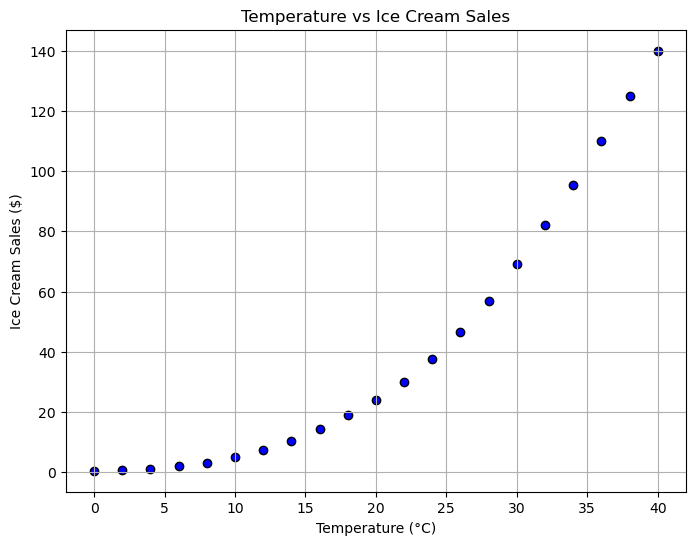

In [6]:
# Plot a scatter plot between Temperature and Ice Cream Sales
plt.figure(figsize=(8, 6))
plt.scatter(data['Temperature (°C)'], data['Ice Cream Sales'], color='blue', edgecolor='k')
plt.title('Temperature vs Ice Cream Sales')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales ($)')
plt.grid(True)
plt.show()

## Dividing the data into X & Y

In [7]:
# Define the independent variable (X) and dependent variable (y)
X = data[['Temperature (°C)']]  # Keep as DataFrame for sklearn
y = data['Ice Cream Sales']

In [8]:
print(X)

    Temperature (°C)
0                  0
1                  2
2                  4
3                  6
4                  8
5                 10
6                 12
7                 14
8                 16
9                 18
10                20
11                22
12                24
13                26
14                28
15                30
16                32
17                34
18                36
19                38
20                40


In [9]:
print(y)

0       0.5
1       0.8
2       1.2
3       2.0
4       3.0
5       5.0
6       7.5
7      10.5
8      14.5
9      19.0
10     24.0
11     30.0
12     37.5
13     46.5
14     57.0
15     69.0
16     82.0
17     95.5
18    110.0
19    125.0
20    140.0
Name: Ice Cream Sales, dtype: float64


## Generating Polynomial Features

In [10]:
# Apply Polynomial Features Transformation
degree = 2  # Change this to try higher degrees
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)

## Splitting the dataset into the Training set and Test set

In [11]:
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

## Training the model

In [12]:
# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
import joblib

# Save the trained model
joblib.dump(model, "polynomial_model.pkl")

# Save the PolynomialFeatures transformer
joblib.dump(poly_features, "poly_features.pkl")

print("Model and PolynomialFeatures saved successfully!")

Model and PolynomialFeatures saved successfully!


## Predicting the Test set results

In [14]:
# Predict using the test data
y_pred = model.predict(X_test)

## Accuracy of the model

In [15]:
# Evaluate the model using R² score
r2 = r2_score(y_test, y_pred)
print(f"\nR² Score on Test Set (degree={degree}): {r2:.4f}")


R² Score on Test Set (degree=2): 0.9881


F:\Anaconda0\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


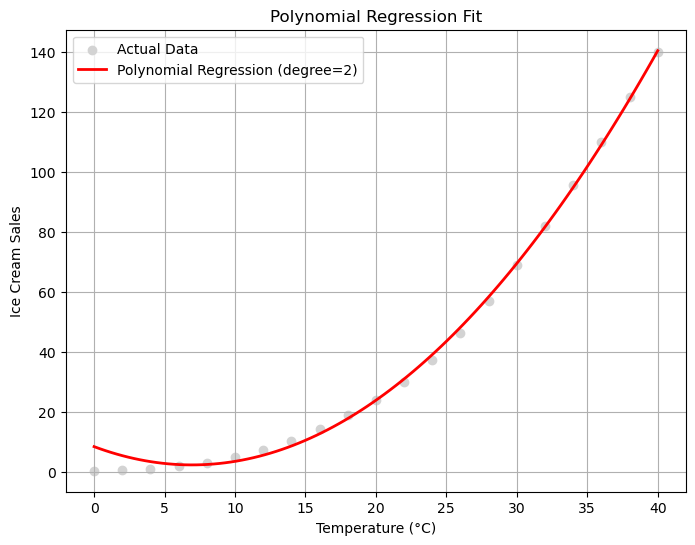

In [16]:
# Plot the polynomial regression curve along with the data points
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='lightgray', label='Actual Data')

# Create smooth range for regression curve
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)
y_range_pred = model.predict(X_range_poly)

# Plot the regression line
plt.plot(X_range, y_range_pred, color='red', linewidth=2, label=f'Polynomial Regression (degree={degree})')

plt.title('Polynomial Regression Fit')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales')
plt.legend()
plt.grid(True)
plt.show()